# Intercept Diagram

The intercept diagram is a tool to evaluate rapidly the dynamic range of a system using information from the two-tone test and NF data.

The following data is needed:

> | Data | Description |
> |---|---|
> | $G$ | Linear gain (dB) |
> | $NF$ | Noise figure of the systems (dB) |
> | $BW$ | Channel bandwidth (Hz) |
> | $P_{out}$ | Power of the carriers in the two tone test (dBm) |
> | $\Delta_2$ | Power difference between fundamental and IM2 product (dB) |
> | $\Delta_3$ | Power difference between fundamental and IM3 product (dB) |
> | $OP_{1dB}$ | Output power at which the actual gain deviates from the linear gain (dBm) |
> | $SI_{min}$ | Minimum signal-to-interference (or signal-to-noise) ratio required for the system to work (dB) |


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

# Force white background in plots
plt.rcParams.update({
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'axes.edgecolor':   'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'text.color':       'black',
    'grid.color':       '#cccccc',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
})


##### SYSTEM PARAMETERS #####
system_name = "RF Amplifier"

##### NOISE PARAMETERS #####
NF   =  2      # [dB] - Noise figure
BW   =  10e6   # [Hz] - Channel bandwidth
T    =  290    # [K]  - System temperature

##### LINEAR GAIN #####
G      = 16   # [dB]  System gain

##### TWO-TONE TEST DATA #####
Pout   = 20   # [dBm] Carrier level at which IMD3 and IMD2 is measured
Delta3 = 35   # [dB]  Difference between the carrier level at the output and the IM3 product
Delta2 = 35   # [dB]  Difference between the carrier level at the output and the IM2 product
OP1dB  = 22   # [dBm] 1 dB Compression point at the output

##### SYSTEM DATA #####
SImin  = 35   # [dB]  Minimum S/I acceptable for the system

## 1) Noise floor

The first step is to determine the noise floor of the system, which depends on the Noise Figure and the channel bandwidth

#### Thermal Noise
Any resistive element at a physical temperature $T$ generates thermal noise.
The available noise power over a bandwidth $B$ is:
$$N_{thermal} = kTB$$
At room temperature ($T = 290\,\text{K}$) over $B = 1\,\text{Hz}$, this evaluates
to the well-known noise floor of $-174\,\text{dBm/Hz}$.


#### Noise Figure
A real receiver adds noise beyond the thermal floor. The **noise figure** quantifies
this degradation as the difference in SNR between input and output:
$$\text{NF} = \text{SNR}_{in} - \text{SNR}_{out} \quad \text{[dB]}$$
Its linear equivalent, the **noise factor** $F$, is:
$$F = 10^{\,\text{NF}/10}$$


#### Total Noise Floor
The total noise power at the output, referred to the input, is
$$N_{total} = F \cdot kTB$$
$$N_{total}\,[\text{dBm}] = \text{NF} + 10\log_{10}(kTB) + 30$$

> **Variables**
> | Symbol | Description |
> |---|---|
> | $k$ | Boltzmann constant ($1.381 \times 10^{-23}$ J/K) |
> | $T$ | System temperature (K) |
> | $B$ | Noise bandwidth (Hz) |
> | $F$ | Noise factor (linear) |
> | $\text{NF}$ | Noise figure (dB) |
> | $N_{thermal}$ | Thermal noise power at input, $kTB$ (W) |
> | $N_{total}$ | Total noise power referred to input, $F{\cdot}kTB$ (W) |

In [34]:
# ─── NOISE POWER CALCULATION ─────────────────────────────────────────────────
k    =  1.380649e-23  # [J/K] - Boltzmann constant

# ─── CALCULATIONS ────────────────────────────────────────────────────────────
# Thermal noise power at input (kTB)
N_thermal_W   = k * T * BW                          # [W]
N_thermal_dBm = 10 * np.log10(N_thermal_W) + 30     # [dBm]

# Noise figure as linear factor
F = 10 ** (NF / 10)                                  # linear (noise factor)

# Total noise power at output referred to input
N_total_W   = F * k * T * BW                        # [W]
N_total_dBm = 10 * np.log10(N_total_W) + 30         # [dBm]

# ─── RESULTS ─────────────────────────────────────────────────────────────────
linewidth = 100
print("─" * linewidth)
print(f"  Temperature      : {T} K")
print(f"  Bandwidth        : {BW/1e6:.1f} MHz")
print(f"  Noise Figure     : {NF} dB")
print("─" * linewidth)
print(f"  kTB  (thermal)   : {N_thermal_W:.3e} W  |  {N_thermal_dBm:.2f} dBm")
print(f"  N_total (F·kTB)  : {N_total_W:.3e} W  |  {N_total_dBm:.2f} dBm")
print("─" * linewidth)

────────────────────────────────────────────────────────────────────────────────────────────────────
  Temperature      : 290 K
  Bandwidth        : 10.0 MHz
  Noise Figure     : 2 dB
────────────────────────────────────────────────────────────────────────────────────────────────────
  kTB  (thermal)   : 4.004e-14 W  |  -103.98 dBm
  N_total (F·kTB)  : 6.346e-14 W  |  -101.98 dBm
────────────────────────────────────────────────────────────────────────────────────────────────────


# 2) Intercept Point (IPn) Diagram

## Two-Tone Test

The intermodulation distortion is often characterized using the intercept points, mainly for the third order. In broadband systems, the second order intermodulation products lie inside the band, the second order intercept point is also needed.

The incercept point is defined as the hypothetical power level at which the fundamental and the intermodulation (IM) product would intersect if extrapolated linearly. Both IP3 and IP2 can be calculated from the two-tone test.

## Second Order Intercept Point (IP2)

The second-order IM product grows 2 dB for every 1 dB increase in input power. Measured with a two-tone test by observing the power difference $\Delta_2$ between the fundamental and the IM2 product:

$$OIP2 = P_{out} + \Delta_2 \qquad IIP2 = OIP2 - G$$

## Third Order Intercept Point (IP3)

The third order IM product grows 3 dB for every 1 dB increase in input power. Measured with a two-tone test by observing the power difference $\Delta_3$ between the fundamental and the IM3 product:

$$OIP3 = P_{out} + \frac{\Delta_3}{2} \qquad IIP3 = OIP3 - G$$


## General Order — IPn

For an IM product of order $n$, the input and output intercept points are:

$$OIPn = P_{out} + \frac{\Delta}{n-1} \qquad IIPn = OIPn - G$$

The output power of the $n$-th order IM product as a function of input power is:

$$P_{out,\,IMn} = n \cdot P_{in} - (n-1) \cdot IIPn + G$$

The IM product grows $n$ dB for every 1 dB increase in input power.


In [35]:
# Equations
def IIP(P_out, G, Delta, n):
    return (P_out - G) + Delta/(n-1) # RF Design Guide. Vizmuller. pg. 36

def PoutIMN(P_in, n, G, IIPN):
    return n*P_in - (n-1)*IIPN + G

In [36]:
# Intercept point calculation

# ─── IP2 CALCULATION ─────────────────────────────────────────────────
IIP2 = IIP(P_out=Pout, G=G, Delta=Delta2, n=2)
OIP2 = IIP2 + G;

# ─── IP3 CALCULATION ─────────────────────────────────────────────────
IIP3 = IIP(P_out=Pout, G=G, Delta=Delta3, n=3)
OIP3 = IIP3 + G;

# ─── Compression point ─────────────────────────────────────────────────
IP1dB = OP1dB - (G-1)


# ─── RESULTS ─────────────────────────────────────────────────────────────────
linewidth = 100
print("─" * linewidth)
print(f"  Output P1dB      : {CPo:.1f} dBm")
print(f"  Input P1dB       : {CPi:.1f} dBm")

print("─" * linewidth)
print(f"  Input IP2        : {IIP2:.1f} dBm")
print(f"  Output IP2       : {OIP2:.1f} dBm")

print("─" * linewidth)
print(f"  Input IP3        : {IIP3:.1f} dBm")
print(f"  Output IP3       : {OIP3:.1f} dBm")
print("─" * linewidth)

────────────────────────────────────────────────────────────────────────────────────────────────────
  Output P1dB      : 22.0 dBm
  Input P1dB       : 7.0 dBm
────────────────────────────────────────────────────────────────────────────────────────────────────
  Input IP2        : 39.0 dBm
  Output IP2       : 55.0 dBm
────────────────────────────────────────────────────────────────────────────────────────────────────
  Input IP3        : 21.5 dBm
  Output IP3       : 37.5 dBm
────────────────────────────────────────────────────────────────────────────────────────────────────


## Output Dynamic Range

### Upper Limit

The upper limit is determined by the linearity of the amplifier. It is the
output power at which the intermodulation products rise above the minimum C/I.

**Third order (IMD3):**

$$P_{out} = P_{in} + G \qquad P_{out,\,IM3} = 3 \cdot P_{in} - 2 \cdot IIP3 + G$$

Setting $P_{out} - P_{out,\,IM3} = CI_{min}$:

$$(P_{in} + G) - (3 \cdot P_{in} - 2 \cdot IIP3 + G) = CI_{min}$$

$$\implies P_{in,\,upper} = IIP3 - \frac{CI_{min}}{2}$$

$$\boxed{P_{out,\,upper} = IIP3 + G - \frac{CI_{min}}{2}}$$

**Second order (IMD2):**

$$P_{out} = P_{in} + G \qquad P_{out,\,IM2} = 2 \cdot P_{in} - IIP2 + G$$

Setting $P_{out} - P_{out,\,IM2} = CI_{min}$:

$$(P_{in} + G) - (2 \cdot P_{in} - IIP2 + G) = CI_{min}$$

$$\implies P_{in,\,upper} = IIP2 - CI_{min}$$

$$\boxed{P_{out,\,upper} = IIP2 + G - CI_{min}}$$

Note that for IMD2 the upper limit degrades twice as fast with $CI_{min}$
compared to IMD3.

---

### Lower Limit

The lower limit is the output power at which the carrier drops below the
noise floor by the minimum SNR required for the system:

$$P_{out,\,lower} = N_{out} + SNR_{min}$$

where $N_{out}$ is the output noise power:

$$N_{out} = NF + 10\log_{10}(kTB) + G$$

---

### Output Dynamic Range

$$DR = P_{out,\,upper} - P_{out,\,lower}$$

In [37]:
# ─── Output Dynamic Range ────────────────────────────────────────────────────────────
# Upper limit — input power at which IMDn rises above SImin
## Check IMD2 limit
Pin_Upper_Limit_IMD2  = IIP2 - SImin
Pout_Upper_Limit_IMD2 = Pin_Upper_Limit_IMD2 + G

## Check IMD3 limit
Pin_Upper_Limit_IMD3  = IIP3 - SImin / 2
Pout_Upper_Limit_IMD3 = Pin_Upper_Limit_IMD3 + G

if (Pout_Upper_Limit_IMD3 < Pout_Upper_Limit_IMD2):
    # IMD3 is worse than IMD2
    Pout_Upper_Limit = Pout_Upper_Limit_IMD3
    Pin_Upper_Limit = Pin_Upper_Limit_IMD3
else:
    # IMD2 is worse than IMD3
    Pout_Upper_Limit = Pout_Upper_Limit_IMD2
    Pin_Upper_Limit = Pin_Upper_Limit_IMD2



# Lower limit — output noise floor + minimum SNR
Pout_Lower_Limit = N_total_dBm + SImin
Pin_Lower_Limit  = Pout_Lower_Limit - G

# Dynamic range (referred to output)
DR_out = Pout_Upper_Limit - Pout_Lower_Limit

print("─" * linewidth)
print("Output Dynamic Range")
print("─" * linewidth)
print(f"  Upper limit (Pout)    : {Pout_Upper_Limit:.2f} dBm")
print(f"  Lower limit (Pout)    : {Pout_Lower_Limit:.2f} dBm")
print(f"  Output Dynamic Range  : {DR_out:.2f} dB")
print("─" * linewidth)

────────────────────────────────────────────────────────────────────────────────────────────────────
Output Dynamic Range
────────────────────────────────────────────────────────────────────────────────────────────────────
  Upper limit (Pout)    : 20.00 dBm
  Lower limit (Pout)    : -66.98 dBm
  Output Dynamic Range  : 86.98 dB
────────────────────────────────────────────────────────────────────────────────────────────────────


## Input Dynamic Range

The input dynamic range is the range of input power levels over which the
system operates correctly — above the sensitivity and below the level at
which intermodulation products exceed the minimum C/I.

$$DR_{in} = P_{in,\,upper} - S$$

---

#### Lower Limit — Sensitivity

The lower limit is the minimum detectable input signal (sensitivity),
defined as the input-referred noise floor plus the minimum SNR required:

$$S = kTB + NF + SNR_{min}$$

where $kTB$ is the thermal noise power at the input:

$$kTB\,(\text{dBm}) = 10\log_{10}(k \cdot T \cdot B) + 30$$

---

#### Upper Limit

The upper limit is the input power at which the intermodulation products
rise above the minimum C/I. Referred to the input from the output upper
limit (assuming no compression):

$$P_{in,\,upper} = P_{out,\,upper} - G = IIPn - \frac{CI_{min}}{n-1}$$

---

#### Input Dynamic Range

Combining both limits:

$$\boxed{DR_{in} = IIPn - \frac{CI_{min}}{n-1} - kTB - NF - SNR_{min}}$$

Note that without compression $DR_{in} = DR_{out}$, since the gain $G$
cancels out in both limits — a useful sanity check.

> **Variables**
> | Symbol | Description |
> |---|---|
> | $S$ | Sensitivity — minimum detectable input power (dBm) |
> | $kTB$ | Thermal noise power at the input (dBm) |
> | $NF$ | Noise figure (dB) |
> | $SNR_{min}$ | Minimum signal-to-noise ratio required (dB) |
> | $CI_{min}$ | Minimum carrier-to-interference ratio required (dB) |
> | $IIPn$ | Input intercept point of order $n$ (dBm) |
> | $G$ | System gain (dB) |
> | $n$ | Order of the intermodulation product |

In [38]:
# ─── INPUT DYNAMIC RANGE ──────────────────────────────────────────────────────
# Upper limit — output upper limit referred back to input (no compression assumed)
Pin_Upper_Limit  = Pout_Upper_Limit - G      # same as IIPn - SImin/(n-1)

# Lower limit — sensitivity: minimum detectable signal at the input
# Sensitivity = kTB + NF + SNR_min
Sensitivity = N_total_dBm - G + SImin           # referred to input (N_total_dBm is at output)

# Input dynamic range
DR_in = Pin_Upper_Limit - Sensitivity

print("─" * linewidth)
print("  Input Dynamic Range")
print("─" * linewidth)
print(f"  Upper limit (Pin)   : {Pin_Upper_Limit:.2f} dBm")
print(f"  Sensitivity (Pin)   : {Sensitivity:.2f} dBm")
print(f"  Input Dynamic Range : {DR_in:.2f} dB")
print("─" * linewidth)


────────────────────────────────────────────────────────────────────────────────────────────────────
  Input Dynamic Range
────────────────────────────────────────────────────────────────────────────────────────────────────
  Upper limit (Pin)   : 4.00 dBm
  Sensitivity (Pin)   : -82.98 dBm
  Input Dynamic Range : 86.98 dB
────────────────────────────────────────────────────────────────────────────────────────────────────


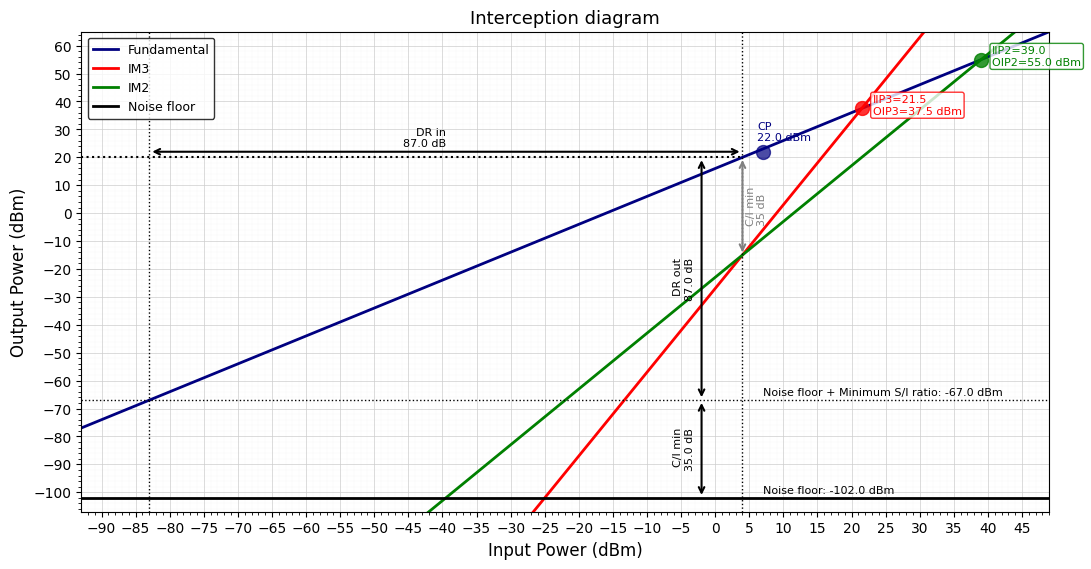

In [40]:
# Plot intercept diagram
plt.close('all')
title = "Interception diagram"

# ─── AXIS DIVISIONS ──────────────────────────────────────────────────────────
x_step = 5    # dB — x-axis major grid step
y_step = 10   # dB — y-axis major grid step

# Plot range
xmin = Pin_Lower_Limit - 10
xmax = max(IIP3, IIP2) + 10
ymin = N_total_dBm - 5
ymax = max(OIP3, OIP2) + 10

# Calculations
P_in        = np.linspace(xmin, xmax, 100)
fundamental = P_in + G
IM3         = PoutIMN(P_in, 3, G, IIP3)
IM2         = PoutIMN(P_in, 2, G, IIP2)

fig, ax = plt.subplots(figsize=(11, 6))

# ─── TRACES ──────────────────────────────────────────────────────────────────
ax.plot(P_in, fundamental, lw=2, color='navy',  label='Fundamental')
ax.plot(P_in, IM3,         lw=2, color='red',   label='IM3')
ax.plot(P_in, IM2,         lw=2, color='green', label='IM2')
ax.axhline(N_total_dBm,    lw=2, color='black', label='Noise floor')

# Operating level dotted line up to Pin_Upper_Limit
level_x = np.linspace(xmin, Pin_Upper_Limit, 100)
ax.plot(level_x, np.full_like(level_x, Pout_Upper_Limit),
        lw=1.5, color='black', ls='dotted')

# ─── POINTS ──────────────────────────────────────────────────────────────────
ax.plot(IIP3, OIP3, 'o', ms=10, color='red',   alpha=0.8, zorder=5)
ax.plot(IIP2, OIP2, 'o', ms=10, color='green', alpha=0.8, zorder=5)
ax.plot(IP1dB,  OP1dB,  'o', ms=10, color='navy',  alpha=0.7, zorder=5)

# ─── POINT LABELS ────────────────────────────────────────────────────────────
ax.annotate(f'IIP3={IIP3:.1f}\nOIP3={OIP3:.1f} dBm',
            xy=(IIP3, OIP3), xytext=(8, -4),
            textcoords='offset points', fontsize=8, color='red',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='red', alpha=0.8))
ax.annotate(f'IIP2={IIP2:.1f}\nOIP2={OIP2:.1f} dBm',
            xy=(IIP2, OIP2), xytext=(8, -4),
            textcoords='offset points', fontsize=8, color='green',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='green', alpha=0.8))
ax.annotate(f'CP\n{CPo:.1f} dBm',
            xy=(CPi, CPo), xytext=(-4, 8),
            textcoords='offset points', fontsize=8, color='navy')

# ─── NOISE FLOOR LABEL ───────────────────────────────────────────────────────
ax.text(IP1dB, N_total_dBm + 0.8,
        f'Noise floor: {N_total_dBm:.1f} dBm',
        fontsize=8, color='black', va='bottom')

# ─── NOISE FLOOR + MINIMUM S/I LABEL ───────────────────────────────────────────────────────
ax.text(IP1dB, N_total_dBm + SImin + 0.8,
        f'Noise floor + Minimum S/I ratio: {N_total_dBm+SImin:.1f} dBm',
        fontsize=8, color='black', va='bottom')

# ─── OUTPUT DYNAMIC RANGE ARROW ──────────────────────────────────────────────
shift_out = 6
ax.annotate('',
    xy    =(Pin_Upper_Limit - shift_out, Pout_Upper_Limit),
    xytext=(Pin_Upper_Limit - shift_out, Pout_Lower_Limit),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(Pin_Upper_Limit - shift_out - 1,
        (Pout_Upper_Limit + Pout_Lower_Limit) / 2,
        f'DR out\n{DR_out:.1f} dB',
        ha='right', va='center', fontsize=8, rotation=90)

# ─── SENSITIVITY / C/I MIN ARROW ─────────────────────────────────────────────
ax.axhline(N_total_dBm + SImin, lw=1, ls='dotted', color='black')
ax.annotate('',
    xy    =(Pin_Upper_Limit - shift_out, N_total_dBm),
    xytext=(Pin_Upper_Limit - shift_out, Pout_Lower_Limit),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(Pin_Upper_Limit - shift_out - 1,
        (Pout_Lower_Limit + N_total_dBm) / 2,
        f'C/I min\n{SImin:.1f} dB',
        ha='right', va='center', fontsize=8, rotation=90)

# ─── C/I MIN ARROW ───────────────────────────────────────────────────────────
ax.annotate('',
    xy    =(Pin_Upper_Limit, Pout_Upper_Limit),
    xytext=(Pin_Upper_Limit, Pout_Upper_Limit - SImin),
    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(Pin_Upper_Limit + 0.5,
        Pout_Upper_Limit - SImin / 2,
        f'C/I min\n{SImin} dB',
        ha='left', va='center', fontsize=8, color='gray', rotation=90)

# ─── INPUT DYNAMIC RANGE ─────────────────────────────────────────────────────
ax.axvline(Pin_Lower_Limit, lw=1, ls='dotted', color='black')
ax.axvline(Pin_Upper_Limit, lw=1, ls='dotted', color='black')
ax.annotate('',
    xy    =(Pin_Lower_Limit, CPo),
    xytext=(Pin_Upper_Limit, CPo),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(0.5 * (Pin_Lower_Limit + Pin_Upper_Limit), CPo + 5,
        f'DR in\n{DR_in:.1f} dB',
        ha='right', va='center', fontsize=8)

# ─── AXIS STEPS ──────────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(ticker.MultipleLocator(x_step))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(x_step / 5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(y_step))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_step / 5))

# ─── FORMATTING ──────────────────────────────────────────────────────────────
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('Input Power (dBm)',  fontsize=12)
ax.set_ylabel('Output Power (dBm)', fontsize=12)
ax.set_title(title, fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, which='major', lw=0.7, alpha=0.7)
ax.grid(True, which='minor', lw=0.3, alpha=0.4, ls=':')
fig.subplots_adjust(left=0.09, right=0.97, top=0.92, bottom=0.12)
plt.show()